# Exploration des températures SYNOP

## Projet de séries temporelles — Partie météo

Ce notebook est consacré à l'**exploration descriptive de la matrice finale des températures SYNOP** obtenue après les étapes de préparation, d'imputation et de contrôle des anomalies.

Le fichier utilisé est :

`data/donnees-traitees/meteo/temperatures_synop_finales.csv`

### Objectifs

L'exploration vise à :

1. charger et contrôler la matrice finale ;
2. décrire la période d'étude et les stations ;
3. étudier la distribution générale des températures ;
4. comparer les stations météorologiques ;
5. analyser l'évolution temporelle des températures ;
6. mettre en évidence la saisonnalité annuelle ;
7. étudier le cycle journalier ;
8. analyser les corrélations entre stations ;
9. préparer les constats utiles pour la suite du projet.

> Ce notebook est une étape d'exploration. Il ne modifie pas les données finales.


## 1. Imports

In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True


## 2. Chargement de la matrice finale

In [26]:
# Recherche de la racine du projet pour permettre l'exécution
# depuis la racine ou depuis le dossier notebooks.

cwd = Path.cwd()

if (cwd / "data").exists():
    RACINE = cwd
elif (cwd.parent / "data").exists():
    RACINE = cwd.parent
else:
    raise FileNotFoundError(
        "Impossible de trouver le dossier 'data'. "
        "Lancez le notebook depuis la racine du projet ou depuis 'notebooks'."
    )

CHEMIN_METEO = (
    RACINE
    / "data"
    / "donnees-traitees"
    / "meteo"
    / "temperatures_synop_finales.csv"
)

print("Racine du projet :", RACINE)
print("Fichier météo :", CHEMIN_METEO)
print("Existe :", CHEMIN_METEO.exists())


Racine du projet : c:\Users\DELL 7280\OneDrive\Desktop\Master2 MALIA\Series temporelles\Projet\Projet-series-temporelles
Fichier météo : c:\Users\DELL 7280\OneDrive\Desktop\Master2 MALIA\Series temporelles\Projet\Projet-series-temporelles\data\donnees-traitees\meteo\temperatures_synop_finales.csv
Existe : True


In [27]:
temperatures = pd.read_csv(
    CHEMIN_METEO,
    index_col=0,
    parse_dates=True,
)

temperatures.index = pd.to_datetime(
    temperatures.index,
    utc=True,
)

temperatures.columns = [
    str(col).zfill(5)
    for col in temperatures.columns
]

temperatures = temperatures.sort_index()

temperatures.head()


,07460,07471,07481,07577,07280,07110,07117,07130,07240,07255,...,07621,07627,07630,07643,07747,07222,07591,07650,07690,07149
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-12-01 00:00:00+00:00,10.7,6.7,8.7,11.7,10.0,12.7,13.1,11.7,11.5,10.5,...,2.7,1.8,3.1,7.2,5.6,12.7,-1.1,8.8,8.3,11.1
2015-12-01 03:00:00+00:00,9.2,6.2,8.2,12.4,8.8,11.9,12.7,11.9,11.5,10.1,...,2.3,-1.1,2.0,6.4,5.5,11.9,-1.5,9.3,7.6,11.7
2015-12-01 06:00:00+00:00,8.3,5.3,8.2,11.8,8.6,12.4,12.1,8.8,11.2,10.0,...,0.5,0.3,0.8,5.7,5.0,11.9,-2.3,11.8,7.4,11.5
2015-12-01 09:00:00+00:00,9.0,6.8,8.1,14.1,9.1,12.7,12.8,12.2,11.4,10.5,...,4.6,5.3,3.9,9.8,11.7,11.9,-0.2,13.7,10.1,11.9
2015-12-01 12:00:00+00:00,11.4,7.1,11.3,14.4,11.4,13.0,13.4,13.5,12.9,11.4,...,12.6,13.1,9.9,16.3,17.1,13.4,8.6,16.3,16.3,12.6


## 3. Contrôles descriptifs initiaux

In [28]:
print("Dimensions :", temperatures.shape)
print("Nombre de timestamps :", len(temperatures))
print("Nombre de stations :", temperatures.shape[1])
print("Première date :", temperatures.index.min())
print("Dernière date :", temperatures.index.max())
print("Timestamps uniques :", temperatures.index.nunique())
print("Doublons temporels :", temperatures.index.duplicated().sum())
print("Valeurs manquantes :", int(temperatures.isna().sum().sum()))


Dimensions : (29472, 40)
Nombre de timestamps : 29472
Nombre de stations : 40
Première date : 2015-12-01 00:00:00+00:00
Dernière date : 2025-12-31 21:00:00+00:00
Timestamps uniques : 29472
Doublons temporels : 0
Valeurs manquantes : 0


In [29]:
# Vérification de la régularité de la grille temporelle

ecarts = temperatures.index.to_series().diff().dropna()

print("Pas temporels observés :")
print(ecarts.value_counts().sort_index())


Pas temporels observés :
timestamp
0 days 03:00:00    29471
Name: count, dtype: int64


### Première lecture

La matrice finale doit être complète et organisée sur une grille régulière de **3 heures**.  
Ces contrôles permettent de vérifier que l'objet utilisé pour l'exploration correspond bien à la sortie finale du pipeline météo.


## 4. Répartition géographique des stations SYNOP

La représentation géographique permet de vérifier la couverture spatiale du réseau utilisé dans l'étude et d'interpréter ensuite les différences de température et les corrélations entre stations.

In [30]:
import json

CHEMIN_POSTES = (
    RACINE / "data" / "donnees-brutes" / "meteo" / "postes_synop.geojson"
)

with open(CHEMIN_POSTES, "r", encoding="utf-8") as f:
    geojson = json.load(f)

print("Nombre total de postes dans le GeoJSON :", len(geojson["features"]))
print("Propriétés disponibles :", list(geojson["features"][0]["properties"].keys()))


Nombre total de postes dans le GeoJSON : 187
Propriétés disponibles : ['Id', 'Nom', 'Altitude', 'Date_ouverture']


In [31]:
# Extraction robuste des coordonnées des stations

lignes = []

for feature in geojson["features"]:
    props = feature.get("properties", {})
    geom = feature.get("geometry", {})

    if geom.get("type") != "Point":
        continue

    coords = geom.get("coordinates", [])
    if len(coords) < 2:
        continue

    identifiant = None
    for cle in ["ID", "id", "Id", "numer_sta", "NUM_POSTE", "num_poste"]:
        if cle in props and props[cle] is not None:
            identifiant = str(props[cle]).zfill(5)
            break

    if identifiant is None:
        continue

    nom = None
    for cle in ["Nom", "nom", "NOM", "nom_usuel", "NOM_USUEL"]:
        if cle in props:
            nom = props[cle]
            break

    lignes.append({
        "station": identifiant,
        "nom": nom,
        "longitude": float(coords[0]),
        "latitude": float(coords[1]),
    })

stations_geo = pd.DataFrame(lignes)

stations_selectionnees = (
    stations_geo[stations_geo["station"].isin(temperatures.columns)]
    .drop_duplicates("station")
    .sort_values("station")
    .reset_index(drop=True)
)

print("Stations dans la matrice finale :", temperatures.shape[1])
print("Stations retrouvées dans le GeoJSON :", len(stations_selectionnees))
print("Longitude :", stations_selectionnees["longitude"].min(),
      "à", stations_selectionnees["longitude"].max())
print("Latitude :", stations_selectionnees["latitude"].min(),
      "à", stations_selectionnees["latitude"].max())

stations_selectionnees.head()


Stations dans la matrice finale : 40
Stations retrouvées dans le GeoJSON : 40
Longitude : -4.391167 à 9.485167
Latitude : 41.918 à 50.57


,station,nom,longitude,latitude
0,07005,ABBEVILLE,1.834000,50.136000
1,07015,LILLE-LESQUIN,3.097500,50.570000
2,07020,PTE DE LA HAGUE,-1.939833,49.725167
3,07027,CAEN-CARPIQUET,-0.456167,49.180000
4,07037,ROUEN-BOOS,1.178333,49.389500


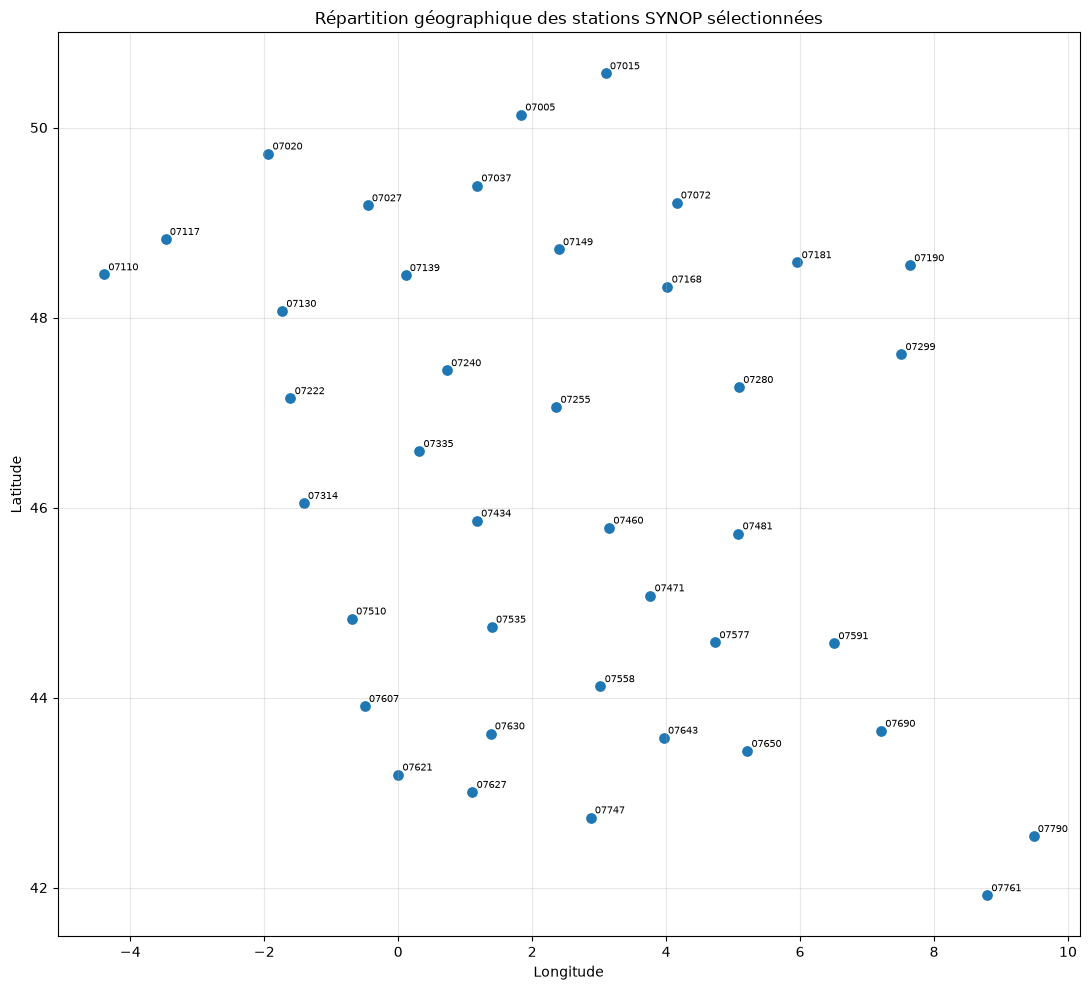

In [32]:
# Carte des 40 stations sélectionnées

fig, ax = plt.subplots(figsize=(11, 10))

ax.scatter(
    stations_selectionnees["longitude"],
    stations_selectionnees["latitude"],
    s=45,
)

for _, ligne in stations_selectionnees.iterrows():
    ax.annotate(
        ligne["station"],
        (ligne["longitude"], ligne["latitude"]),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=7,
    )

ax.set_title("Répartition géographique des stations SYNOP sélectionnées")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Analyse de la figure

Cette carte représente uniquement les stations effectivement utilisées dans la matrice finale. Le réseau doit contenir **40 stations** et couvrir différentes zones de la France métropolitaine. Cette dispersion géographique est importante : elle permet de représenter des contextes climatiques contrastés et explique une partie des différences de niveau moyen et de variabilité observées entre stations.

La carte servira également à interpréter la matrice de corrélation : les stations soumises à des conditions météorologiques proches peuvent présenter des évolutions fortement corrélées, même si la proximité géographique n'est pas le seul facteur explicatif.

## 4. Statistiques descriptives globales

In [33]:
valeurs = temperatures.stack()

statistiques_globales = valeurs.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

statistiques_globales


count    1.178880e+06
mean     1.317847e+01
std      7.394648e+00
min     -1.660000e+01
1%      -2.200000e+00
5%       1.500000e+00
25%      8.000000e+00
50%      1.270000e+01
75%      1.804918e+01
95%      2.620000e+01
99%      3.110000e+01
max      4.230000e+01
dtype: float64

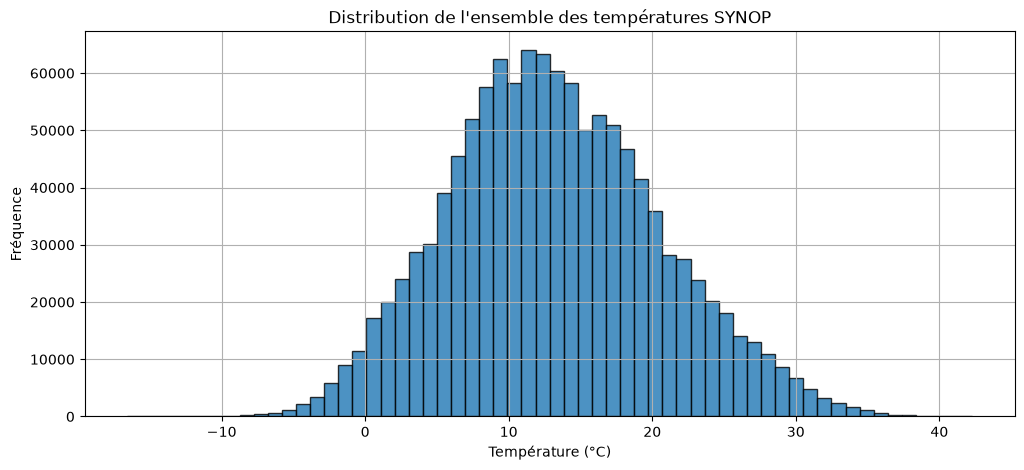

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(
    valeurs,
    bins=60,
    edgecolor="black",
    alpha=0.8,
)

ax.set_title("Distribution de l'ensemble des températures SYNOP")
ax.set_xlabel("Température (°C)")
ax.set_ylabel("Fréquence")

plt.show()


### Analyse de la figure

La distribution porte sur **1 178 880 températures**. La température moyenne est de **13,18 °C** et la médiane de **12,70 °C**, ce qui indique une distribution globalement centrée autour de 13 °C. La moitié des observations se situe approximativement entre **8,0 °C et 18,05 °C**. L'étendue est importante, de **−16,6 °C à 42,3 °C**, ce qui est cohérent avec un réseau national observé pendant plusieurs saisons et plusieurs années. Les quantiles montrent que 90 % des valeurs sont environ comprises entre **1,5 °C et 26,2 °C**.

## 5. Comparaison des stations

In [35]:
resume_stations = pd.DataFrame({
    "moyenne": temperatures.mean(),
    "ecart_type": temperatures.std(),
    "minimum": temperatures.min(),
    "q25": temperatures.quantile(0.25),
    "mediane": temperatures.median(),
    "q75": temperatures.quantile(0.75),
    "maximum": temperatures.max(),
})

resume_stations.index.name = "station"

resume_stations.head(10)


,moyenne,ecart_type,minimum,q25,mediane,q75,maximum
station,,,,,,,
07460,12.873913,7.901876,-12.1,7.2,12.6,18.2,40.6
07471,9.794072,7.929102,-16.6,4.0,9.3,15.0,37.2
07481,13.528286,8.178113,-10.0,7.5,13.1,19.3,39.5
07577,14.748640,8.032921,-6.1,8.5,14.1,20.5,40.0
07280,12.153032,8.128695,-10.8,6.1,11.5,17.8,38.9
07110,12.025596,5.032090,-6.5,8.7,11.8,15.4,38.8
07117,12.579316,4.296350,-4.3,9.5,12.5,15.7,35.2
07130,12.606162,6.531940,-6.7,8.2,12.3,16.9,40.2
07240,12.908193,7.246117,-8.2,7.8,12.3,17.7,40.5


In [36]:
resume_stations.sort_values("moyenne")


,moyenne,ecart_type,minimum,q25,mediane,q75,maximum
station,,,,,,,
07471,9.794072,7.929102,-16.6,4.00000,9.300000,15.0,37.2
07181,11.328236,7.831329,-12.0,5.60000,10.800000,16.8,39.4
07591,11.346579,8.534426,-10.5,4.60000,10.790692,17.2,38.1
07037,11.396013,6.678215,-9.0,6.70000,11.000000,15.9,40.9
07072,11.578475,7.552590,-10.6,6.20000,11.100000,16.6,40.9
07005,11.587817,6.345594,-7.5,7.20000,11.300000,15.9,41.2
07558,11.704853,7.606381,-11.4,6.10000,10.800000,16.8,38.7
07299,11.752856,8.258089,-16.1,5.50000,11.200000,17.4,38.3
07139,11.791286,6.898384,-9.4,7.00000,11.400000,16.4,39.3


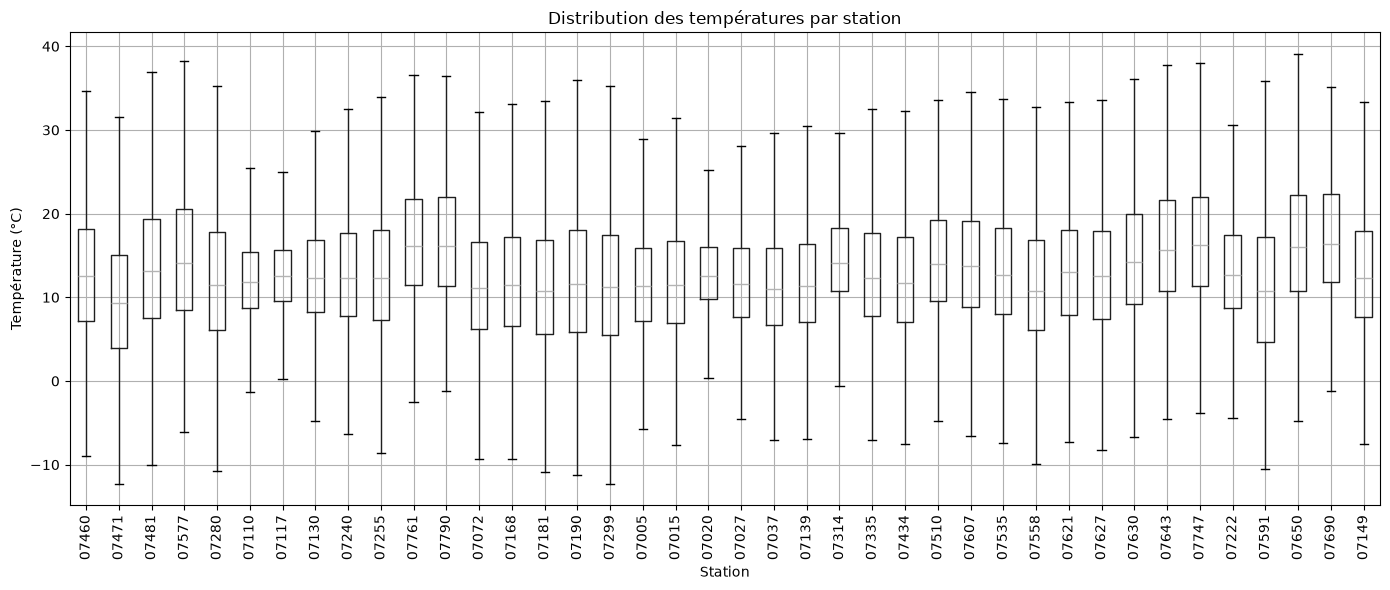

In [37]:
fig, ax = plt.subplots(figsize=(14, 6))

temperatures.boxplot(
    ax=ax,
    rot=90,
    showfliers=False,
)

ax.set_title("Distribution des températures par station")
ax.set_xlabel("Station")
ax.set_ylabel("Température (°C)")

plt.tight_layout()
plt.show()


### Analyse de la figure

Les distributions diffèrent nettement selon les stations. La moyenne la plus faible du tableau est observée à **07471 (9,79 °C)**, tandis que **07690 atteint 16,95 °C** en moyenne. Les stations ne présentent pas non plus la même variabilité : par exemple **07020** et **07117** ont des écarts-types proches de 4 °C, alors que plusieurs stations dépassent 8 °C. Les boxplots confirment donc une hétérogénéité spatiale réelle des niveaux et amplitudes thermiques, ce qui justifie de conserver l'information provenant de plusieurs stations plutôt que de considérer toutes les séries comme interchangeables.

## 6. Évolution temporelle globale

In [38]:
temperature_moyenne = temperatures.mean(axis=1)

temperature_moyenne.head()


timestamp
2015-12-01 00:00:00+00:00     9.0375
2015-12-01 03:00:00+00:00     8.5150
2015-12-01 06:00:00+00:00     8.3125
2015-12-01 09:00:00+00:00     9.8300
2015-12-01 12:00:00+00:00    12.6575
dtype: float64

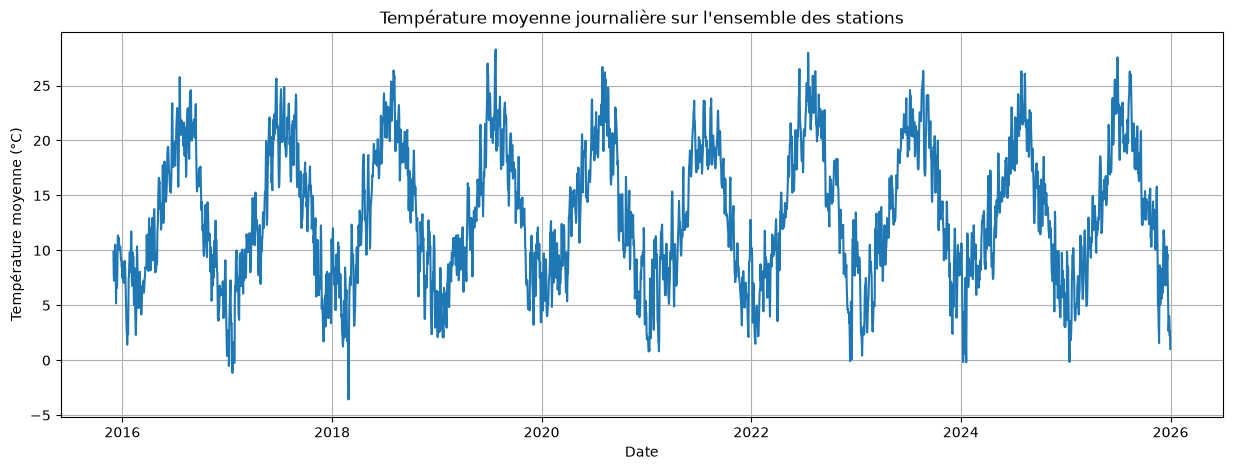

In [39]:
moyenne_journaliere = temperature_moyenne.resample("D").mean()

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(moyenne_journaliere.index, moyenne_journaliere)

ax.set_title("Température moyenne journalière sur l'ensemble des stations")
ax.set_xlabel("Date")
ax.set_ylabel("Température moyenne (°C)")

plt.show()


### Analyse de la figure

La série journalière fait apparaître une alternance régulière entre périodes froides et chaudes. Cette répétition au fil des années met en évidence une **saisonnalité annuelle forte**. L'agrégation sur les 40 stations réduit les fluctuations locales et fait ressortir la dynamique thermique commune à l'ensemble du territoire. Les pics et creux ponctuels correspondent à des épisodes météorologiques de courte durée qui restent visibles malgré l'agrégation spatiale.

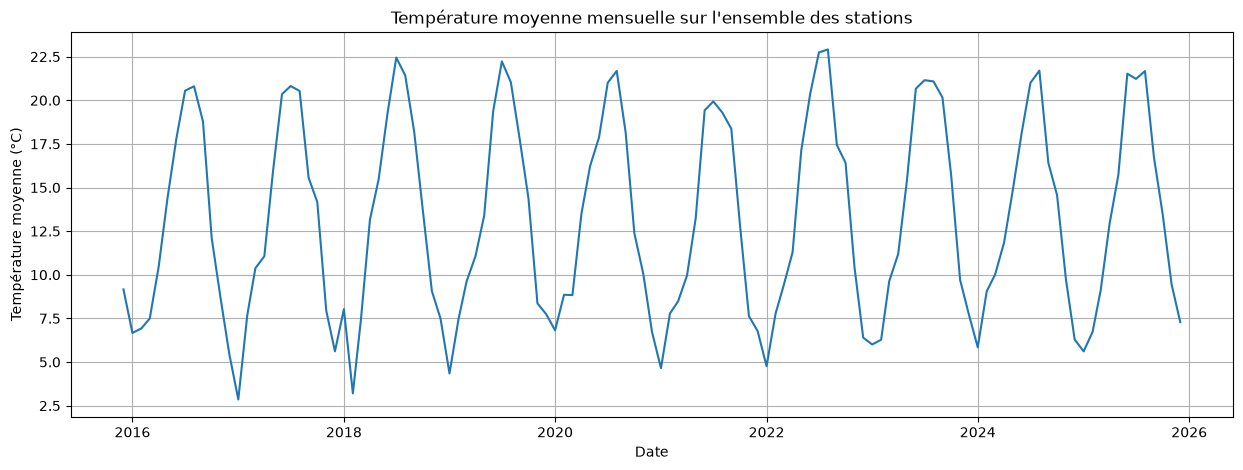

In [40]:
moyenne_mensuelle = temperature_moyenne.resample("MS").mean()

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(moyenne_mensuelle.index, moyenne_mensuelle)

ax.set_title("Température moyenne mensuelle sur l'ensemble des stations")
ax.set_xlabel("Date")
ax.set_ylabel("Température moyenne (°C)")

plt.show()


### Analyse de la figure

Le passage à l'échelle mensuelle lisse les variations de court terme et rend le cycle annuel particulièrement visible. Les minima apparaissent pendant les mois d'hiver et les maxima pendant l'été, avec une montée progressive au printemps puis une diminution à l'automne. Cette structure répétitive montre que la composante saisonnière devra être prise en compte dans la suite de l'étude, notamment lors de la mise en relation avec la consommation électrique.

## 7. Saisonnalité annuelle

In [41]:
mensuel = pd.DataFrame({
    "temperature": temperature_moyenne,
})

mensuel["mois"] = mensuel.index.month

profil_mensuel = (
    mensuel
    .groupby("mois")["temperature"]
    .agg(["mean", "std", "min", "max"])
)

profil_mensuel


,mean,std,min,max
mois,,,,
1,5.557879,3.483099,-4.274597,14.590000
2,7.184043,3.601825,-6.447144,20.140585
3,9.040768,3.634167,-0.585000,22.565000
4,11.654568,4.189065,0.373416,25.435000
5,15.172268,4.138563,3.442500,28.367500
6,19.484932,4.263037,9.565000,33.964335
7,21.309068,4.062572,11.007500,36.090000
8,21.213447,4.317563,11.010000,33.595000
9,17.752072,4.322642,6.825000,31.282500


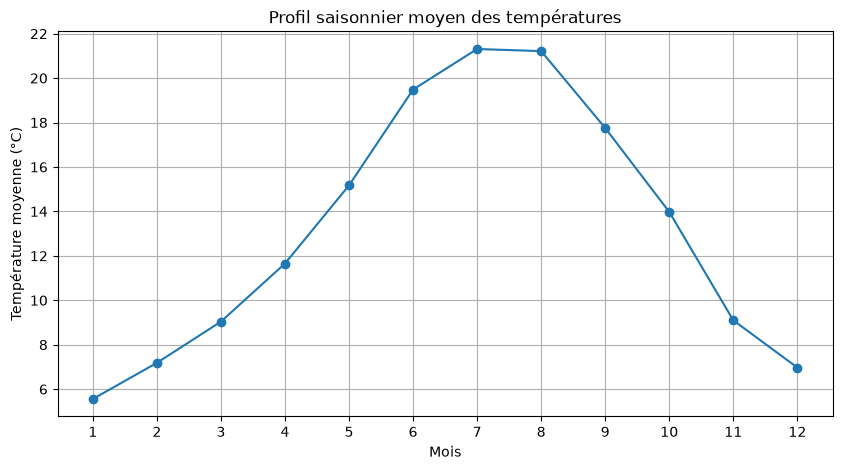

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    profil_mensuel.index,
    profil_mensuel["mean"],
    marker="o",
)

ax.set_xticks(range(1, 13))
ax.set_title("Profil saisonnier moyen des températures")
ax.set_xlabel("Mois")
ax.set_ylabel("Température moyenne (°C)")

plt.show()


### Analyse de la figure

Le profil mensuel confirme quantitativement la saisonnalité. **Janvier est le mois le plus froid en moyenne (5,56 °C)**. La température augmente progressivement jusqu'à **juillet (21,31 °C)**, très légèrement devant août (**21,21 °C**), puis diminue à partir de septembre. L'amplitude entre janvier et juillet est donc d'environ **15,75 °C**. Cette saisonnalité très marquée constitue une caractéristique essentielle de la variable température pour la modélisation ultérieure.

## 8. Cycle journalier

In [43]:
horaire = pd.DataFrame({
    "temperature": temperature_moyenne,
})

horaire["heure_utc"] = horaire.index.hour

profil_horaire = (
    horaire
    .groupby("heure_utc")["temperature"]
    .agg(["mean", "std", "min", "max"])
)

profil_horaire


,mean,std,min,max
heure_utc,,,,
0,11.011987,5.448559,-5.849808,24.061385
3,10.183807,5.218495,-6.384124,22.200700
6,10.398524,5.691701,-6.447144,23.900000
9,13.672976,6.754932,-3.995000,30.750000
12,16.371136,6.854582,-1.347500,34.330000
15,16.853735,7.016138,-0.450000,36.090000
18,14.676506,7.024039,-2.502500,33.928869
21,12.259128,5.884030,-4.472500,27.087500


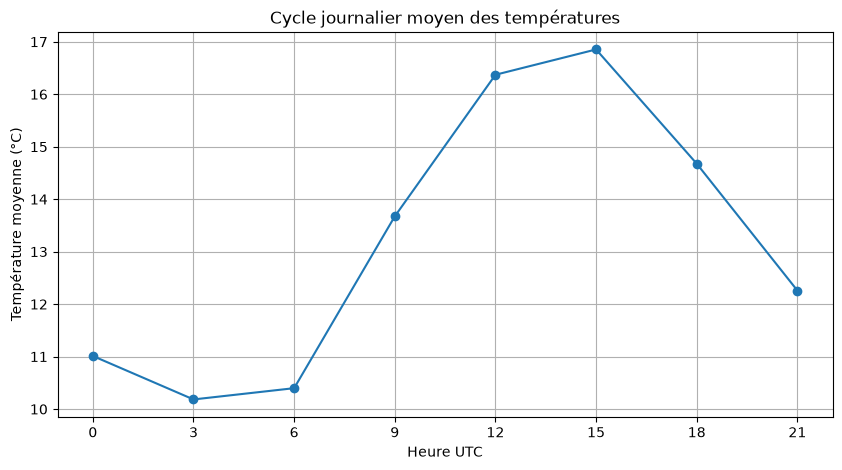

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    profil_horaire.index,
    profil_horaire["mean"],
    marker="o",
)

ax.set_xticks(sorted(horaire["heure_utc"].unique()))
ax.set_title("Cycle journalier moyen des températures")
ax.set_xlabel("Heure UTC")
ax.set_ylabel("Température moyenne (°C)")

plt.show()


### Analyse de la figure

Un cycle intra-journalier net apparaît également. La moyenne est minimale vers **03:00 UTC (10,18 °C)** puis augmente au cours de la matinée. Elle atteint son maximum à **15:00 UTC (16,85 °C)** avant de diminuer en soirée. L'amplitude moyenne entre le minimum et le maximum journaliers est d'environ **6,67 °C**. L'heure d'observation est donc une composante pertinente de la structure temporelle des températures.

## 9. Corrélations entre stations

In [45]:
correlations = temperatures.corr()

correlations.iloc[:10, :10]


,07460,07471,07481,07577,07280,07110,07117,07130,07240,07255
07460,1.000000,0.964816,0.962273,0.928504,0.949028,0.833134,0.834440,0.893623,0.941501,0.959520
07471,0.964816,1.000000,0.953416,0.942966,0.938028,0.820326,0.822234,0.874493,0.917607,0.935034
07481,0.962273,0.953416,1.000000,0.953205,0.962897,0.816734,0.829514,0.881078,0.933222,0.949306
07577,0.928504,0.942966,0.953205,1.000000,0.945594,0.814471,0.830266,0.870071,0.910721,0.924604
07280,0.949028,0.938028,0.962897,0.945594,1.000000,0.829102,0.837825,0.893305,0.942704,0.959546
07110,0.833134,0.820326,0.816734,0.814471,0.829102,1.000000,0.924179,0.930361,0.882503,0.855791
07117,0.834440,0.822234,0.829514,0.830266,0.837825,0.924179,1.000000,0.905067,0.880585,0.857120
07130,0.893623,0.874493,0.881078,0.870071,0.893305,0.930361,0.905067,1.000000,0.951784,0.926021
07240,0.941501,0.917607,0.933222,0.910721,0.942704,0.882503,0.880585,0.951784,1.000000,0.976878
07255,0.959520,0.935034,0.949306,0.924604,0.959546,0.855791,0.857120,0.926021,0.976878,1.000000


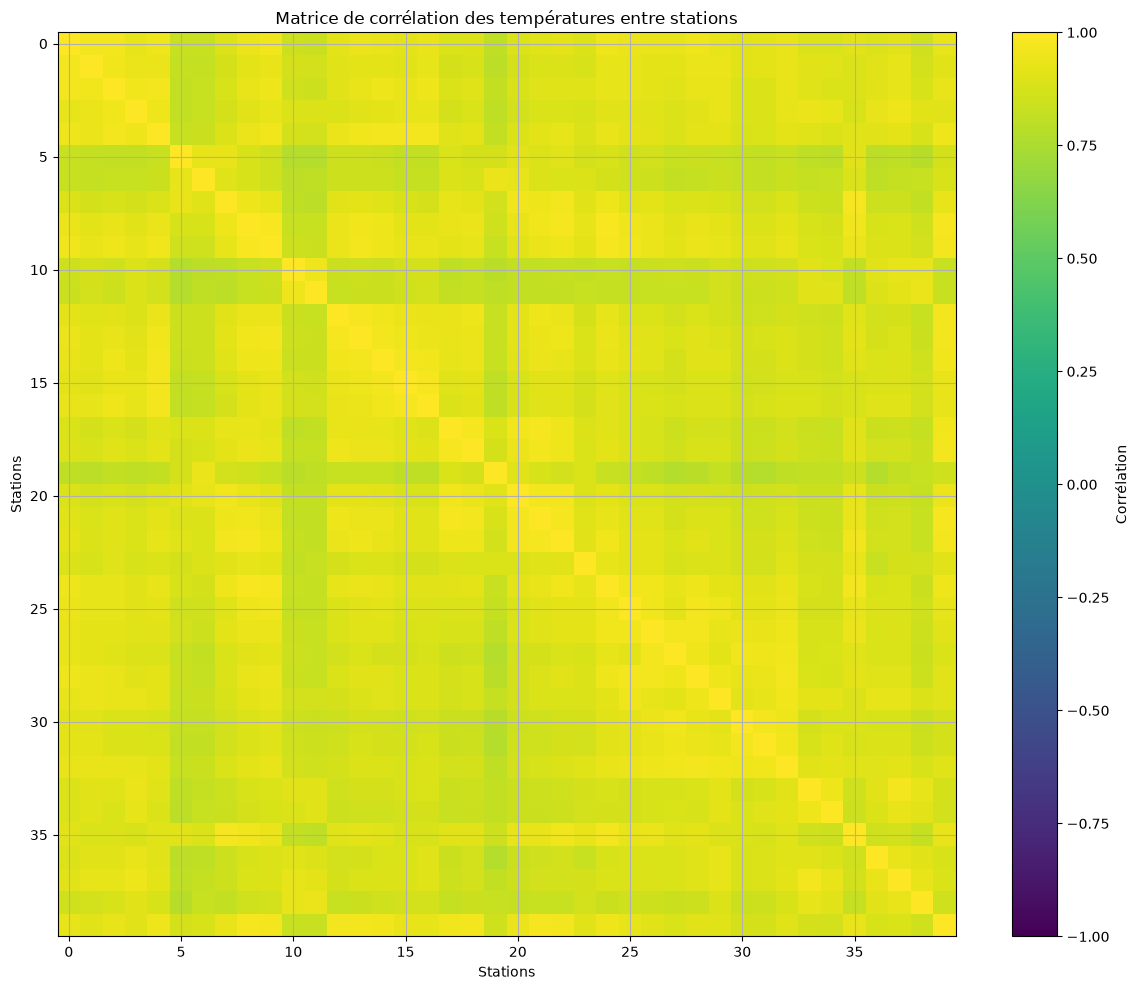

In [46]:
fig, ax = plt.subplots(figsize=(12, 10))

image = ax.imshow(
    correlations,
    aspect="auto",
    vmin=-1,
    vmax=1,
)

ax.set_title("Matrice de corrélation des températures entre stations")
ax.set_xlabel("Stations")
ax.set_ylabel("Stations")

fig.colorbar(
    image,
    ax=ax,
    label="Corrélation",
)

plt.tight_layout()
plt.show()


### Analyse de la figure

La matrice montre des corrélations positives très fortes entre de nombreuses stations, ce qui traduit l'existence d'une dynamique thermique commune à l'échelle du territoire. Les couples les plus corrélés atteignent des coefficients proches de 1 : **07240–07335 (r = 0,9800)**, **07240–07255 (r = 0,9769)** et **07005–07037 (r = 0,9764)**. Ces résultats expliquent pourquoi l'information des stations voisines ou fortement corrélées a été efficace lors de l'imputation spatiale. Ils montrent aussi qu'une partie importante de l'information météorologique est partagée entre stations.

In [47]:
# Corrélations hors diagonale

corr_sans_diag = correlations.copy()

for station in corr_sans_diag.columns:
    corr_sans_diag.loc[station, station] = np.nan

corr_long = (
    corr_sans_diag
    .stack()
    .rename("correlation")
    .reset_index()
)

corr_long.columns = ["station_1", "station_2", "correlation"]

corr_long["paire"] = corr_long.apply(
    lambda ligne: tuple(sorted([ligne["station_1"], ligne["station_2"]])),
    axis=1,
)

corr_uniques = (
    corr_long
    .drop_duplicates("paire")
    .drop(columns="paire")
)

top_correlations = corr_uniques.sort_values(
    "correlation",
    ascending=False,
).head(20)

top_correlations


,station_1,station_2,correlation
344,07240,07335,0.980029
329,07240,07255,0.976878
701,07005,07037,0.976380
698,07005,07015,0.976247
616,07190,07299,0.975751
493,07072,07168,0.975269
862,07037,07139,0.974066
342,07240,07139,0.972962
359,07240,07149,0.972671
879,07037,07149,0.971680


## 10. Températures extrêmes

In [48]:
# 20 températures les plus basses

(
    temperatures
    .stack()
    .sort_values()
    .head(20)
    .rename("temperature")
    .to_frame()
)


,,temperature
timestamp,,
2018-02-28 06:00:00+00:00,07471,-16.6
2021-02-12 06:00:00+00:00,07299,-16.1
2021-02-14 06:00:00+00:00,07299,-15.6
2018-02-28 03:00:00+00:00,07471,-15.4
2021-02-13 03:00:00+00:00,07299,-15.0
2021-02-13 06:00:00+00:00,07299,-14.9
2021-02-12 03:00:00+00:00,07299,-14.8
2018-02-27 06:00:00+00:00,07471,-14.6
2021-02-12 00:00:00+00:00,07299,-14.6


In [49]:
# 20 températures les plus élevées

(
    temperatures
    .stack()
    .sort_values(ascending=False)
    .head(20)
    .rename("temperature")
    .to_frame()
)


temperature
timestamp                                   
2023-08-23 15:00:00+00:00 07630         42.3
2019-06-28 15:00:00+00:00 07643         42.0
                          07747         41.9
2022-07-18 15:00:00+00:00 07222         41.8
2023-08-24 15:00:00+00:00 07630         41.8
2023-08-23 15:00:00+00:00 07607         41.4
2019-07-25 15:00:00+00:00 07149         41.4
                          07015         41.4
                          07168         41.3
                          07005         41.2
2025-08-11 15:00:00+00:00 07630         40.9
2019-07-25 15:00:00+00:00 07037         40.9
                          07072         40.9
                          07255         40.8
2019-07-25 12:00:00+00:00 07168         40.6
2022-06-18 15:00:00+00:00 07607         40.6
2019-06-26 15:00:00+00:00 07460         40.6
2023-08-24 12:00:00+00:00 07607         40.6
2019-07-25 15:00:00+00:00 07240         40.5
2025-08-11 15:00:00+00:00 07607         40.5

### Analyse des températures extrêmes

Les valeurs les plus froides sont concentrées principalement sur quelques épisodes hivernaux : le minimum global est **−16,6 °C** à la station **07471**, le 28 février 2018 à 06:00 UTC. Plusieurs valeurs très basses concernent aussi la station **07299** en février 2021.

À l'opposé, le maximum global est **42,3 °C** à la station **07630**, le 23 août 2023 à 15:00 UTC. Plusieurs températures supérieures à 40 °C apparaissent lors d'épisodes estivaux, notamment en juin-juillet 2019, juillet 2022, août 2023 et août 2025. La concentration temporelle de ces extrêmes est cohérente avec des épisodes de froid ou de chaleur affectant simultanément plusieurs stations.

## 11. Synthèse de l'exploration météorologique

La matrice finale contient **29 472 timestamps et 40 stations**, soit **1 178 880 températures**, sur la période allant du **1er décembre 2015 au 31 décembre 2025**. La grille est parfaitement régulière avec un pas de **3 heures**, sans doublon temporel ni valeur manquante. Le jeu de données obtenu après le pipeline de préparation est donc complet et directement exploitable pour l'analyse.

Sur l'ensemble des stations, la température moyenne est de **13,18 °C** et la médiane de **12,70 °C**. Les températures s'étendent de **−16,6 °C à 42,3 °C**. Des différences importantes existent entre stations : les moyennes vont approximativement de **9,79 °C** à **16,95 °C**, ce qui met en évidence l'hétérogénéité spatiale du réseau météorologique.

L'analyse temporelle révèle deux structures principales. D'abord, une **forte saisonnalité annuelle** : la température moyenne passe d'environ **5,56 °C en janvier** à **21,31 °C en juillet**. Ensuite, un **cycle journalier** apparaît clairement, avec un minimum moyen vers **03:00 UTC (10,18 °C)** et un maximum vers **15:00 UTC (16,85 °C)**.

Les séries des différentes stations sont fortement dépendantes. Plusieurs corrélations dépassent **0,97**, avec un maximum observé de **0,9800** pour le couple **07240–07335**. Cette forte cohérence spatiale confirme l'intérêt de l'information multistation et est cohérente avec les performances obtenues précédemment lors de l'imputation spatiale.

Enfin, les températures extrêmes restent concentrées dans des épisodes météorologiques identifiables : le minimum de **−16,6 °C** est observé en février 2018 et le maximum de **42,3 °C** en août 2023. Après la correction contrôlée des anomalies réalisée dans le pipeline, ces extrêmes constituent des observations à conserver et non des valeurs à supprimer automatiquement.

### Conclusion pour la suite du projet

L'exploration montre donc que la température possède une structure à la fois **spatiale, saisonnière et intra-journalière**. Ces caractéristiques devront être prises en compte lors de la construction du dataset commun avec la consommation électrique. À ce stade, l'objectif reste descriptif : le choix définitif des variables météorologiques destinées à la modélisation sera effectué dans l'étape suivante avec les autres composantes du projet.